# Decision Tree Training Notebook

This notebook follows the same workflow as the Python training script.
The only model-specific change is the classifier used at the end.

In [51]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap
from sklearn.tree import DecisionTreeClassifier

ROOT_DIR = Path.cwd().resolve().parent.parent
PYTHON_DIR = ROOT_DIR / "python"
if str(PYTHON_DIR) not in sys.path:
    sys.path.append(str(PYTHON_DIR))

from common import (  # noqa: E402
    CLASS_ORDER,
    coerce_feature_types,
    evaluate_predictions,
    load_tabular_file,
    build_preprocessor,
    split_feature_columns,
    infer_numeric_like_columns,
    standardize_columns,
    find_column,
    clean_rating_label,
    create_rating_group,
    IDENTIFIER_ALIASES,
    TARGET_ALIASES,
)

# Auto-detect the first CSV or Excel file in the data/ directory.
_data_dir = ROOT_DIR / "data"
_candidates = sorted(
    list(_data_dir.glob("*.csv")) + list(_data_dir.glob("*.xlsx")) + list(_data_dir.glob("*.xls"))
)
if not _candidates:
    raise FileNotFoundError(
        f"No CSV or Excel file found in {_data_dir}. ",
        "Please place your dataset there and re-run this cell.",
    )
DATA_PATH = _candidates[0]
print(f"Using dataset: {DATA_PATH}")
print("Imports ready")

Using dataset: C:\Users\24042626\Downloads\DFT Y3 (1)\C300 FYP\New Code\data\set A corporate_rating.csv
Imports ready


In [52]:
# Step 1: Load the dataset.
raw_df = load_tabular_file(str(DATA_PATH))
df = standardize_columns(raw_df)
print(df.shape)
df.head()

(2029, 31)


,Rating,Name,Symbol,Rating Agency Name,Date,Sector,currentRatio,quickRatio,cashRatio,daysOfSalesOutstanding,...,effectiveTaxRate,freeCashFlowOperatingCashFlowRatio,freeCashFlowPerShare,cashPerShare,companyEquityMultiplier,ebitPerRevenue,enterpriseValueMultiple,operatingCashFlowPerShare,operatingCashFlowSalesRatio,payablesTurnover
0,A,Whirlpool Corporation,WHR,Egan-Jones Ratings Company,11/27/2015,Consumer Durables,0.945894,0.426395,0.099690,44.203245,...,0.202716,0.437551,6.810673,9.809403,4.008012,0.049351,7.057088,15.565438,0.058638,3.906655
1,BBB,Whirlpool Corporation,WHR,Egan-Jones Ratings Company,2/13/2014,Consumer Durables,1.033559,0.498234,0.203120,38.991156,...,0.074155,0.541997,8.625473,17.402270,3.156783,0.048857,6.460618,15.914250,0.067239,4.002846
2,BBB,Whirlpool Corporation,WHR,Fitch Ratings,3/6/2015,Consumer Durables,0.963703,0.451505,0.122099,50.841385,...,0.214529,0.513185,9.693487,13.103448,4.094575,0.044334,10.491970,18.888889,0.074426,3.483510
3,BBB,Whirlpool Corporation,WHR,Fitch Ratings,6/15/2012,Consumer Durables,1.019851,0.510402,0.176116,41.161738,...,1.816667,-0.147170,-1.015625,14.440104,3.630950,-0.012858,4.080741,6.901042,0.028394,4.581150
4,BBB,Whirlpool Corporation,WHR,Standard & Poor's Ratings Services,10/24/2016,Consumer Durables,0.957844,0.495432,0.141608,47.761126,...,0.166966,0.451372,7.135348,14.257556,4.012780,0.053770,8.293505,15.808147,0.058065,3.857790


In [53]:
# Step 2: Check missing values and duplicates.
missing_values = df.isna().sum().sort_values(ascending=False)
duplicate_rows = int(df.duplicated().sum())
print(missing_values[missing_values > 0])
print("Duplicate rows:", duplicate_rows)

Series([], dtype: int64)
Duplicate rows: 0


In [54]:
# Step 3: Create the RatingGroup target.
rating_column = find_column(df, TARGET_ALIASES)
if rating_column is None:
    raise ValueError("No rating column found in the dataset.")

working_df = df.copy()
working_df[rating_column] = working_df[rating_column].apply(clean_rating_label)
working_df["RatingGroup"] = working_df[rating_column].apply(create_rating_group)
working_df = working_df.dropna(subset=["RatingGroup"]).copy()

identifier_columns = []
for alias in IDENTIFIER_ALIASES:
    found = find_column(working_df, [alias])
    if found and found not in identifier_columns:
        identifier_columns.append(found)

if rating_column not in identifier_columns:
    identifier_columns.append(rating_column)

working_df = working_df.drop(columns=identifier_columns, errors="ignore")
working_df = infer_numeric_like_columns(working_df, exclude_columns=["RatingGroup"])
print(working_df["RatingGroup"].value_counts())

RatingGroup
Speculative        792
Investment-Low     671
Investment-High    494
Distressed          72
Name: count, dtype: int64


In [55]:
# Step 4: Select features and prepare the training data.
feature_columns = [column for column in working_df.columns if column != "RatingGroup"]
numeric_columns, categorical_columns = split_feature_columns(working_df, "RatingGroup", [])
X = working_df[feature_columns].copy()
X = coerce_feature_types(X, numeric_columns, categorical_columns)
y = working_df["RatingGroup"].copy()
print("Numeric columns:", numeric_columns)
print("Categorical columns:", categorical_columns)

Numeric columns: ['currentRatio', 'quickRatio', 'cashRatio', 'daysOfSalesOutstanding', 'netProfitMargin', 'pretaxProfitMargin', 'grossProfitMargin', 'operatingProfitMargin', 'returnOnAssets', 'returnOnCapitalEmployed', 'returnOnEquity', 'assetTurnover', 'fixedAssetTurnover', 'debtEquityRatio', 'debtRatio', 'effectiveTaxRate', 'freeCashFlowOperatingCashFlowRatio', 'freeCashFlowPerShare', 'cashPerShare', 'companyEquityMultiplier', 'ebitPerRevenue', 'enterpriseValueMultiple', 'operatingCashFlowPerShare', 'operatingCashFlowSalesRatio', 'payablesTurnover']
Categorical columns: ['Sector']


In [56]:
# Step 5: Split the dataset and train the model.
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.pipeline import Pipeline

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.30,
    random_state=42,
    stratify=y_encoded,
)

pipeline = Pipeline(
    steps=[
        ("preprocessor", build_preprocessor(numeric_columns, categorical_columns)),
        ("model", DecisionTreeClassifier(random_state=42)),
    ]
)
pipeline.fit(X_train, y_train)
print("Model trained")

Model trained


In [57]:
# Step 6: Evaluate the trained model.
y_pred = pipeline.predict(X_test)
y_test_labels = label_encoder.inverse_transform(y_test)
y_pred_labels = label_encoder.inverse_transform(y_pred.astype(int))
metrics = evaluate_predictions(y_test_labels, y_pred_labels, CLASS_ORDER)
print(metrics["accuracy"])
print(metrics["classification_report_text"])


0.5500821018062397
                 precision    recall  f1-score   support

Investment-High       0.51      0.58      0.54       148
 Investment-Low       0.52      0.48      0.50       201
    Speculative       0.62      0.61      0.62       238
     Distressed       0.33      0.32      0.33        22

       accuracy                           0.55       609
      macro avg       0.50      0.50      0.50       609
   weighted avg       0.55      0.55      0.55       609



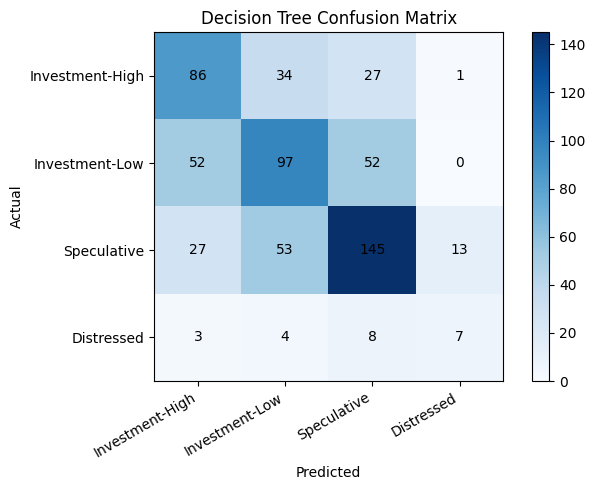

In [58]:
# Step 7: Show the confusion matrix.
cm = np.array(metrics["confusion_matrix"])
fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(len(CLASS_ORDER)))
ax.set_yticks(range(len(CLASS_ORDER)))
ax.set_xticklabels(CLASS_ORDER, rotation=30, ha="right")
ax.set_yticklabels(CLASS_ORDER)
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title("Decision Tree Confusion Matrix")

for row_index in range(cm.shape[0]):
    for column_index in range(cm.shape[1]):
        ax.text(
            column_index,
            row_index,
            cm[row_index, column_index],
            ha="center",
            va="center",
            color="black",
        )

fig.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()


## Hyperparameter Tuning and Model Comparison

This section keeps the existing data split and preprocessing workflow unchanged.
It compares the current baseline decision tree against a GridSearchCV-tuned tree using weighted F1 as the search metric.


Best hyperparameters:
{'model__class_weight': 'balanced', 'model__criterion': 'gini', 'model__max_depth': None, 'model__max_features': 'log2', 'model__min_samples_leaf': 1, 'model__min_samples_split': 2, 'model__splitter': 'random'}

Best cross-validation score (weighted F1): 0.548101

Baseline metrics:
{'training_accuracy': 1.0, 'testing_accuracy': 0.5500821018062397, 'accuracy': 0.5500821018062397, 'weighted_f1': 0.5497741573021249, 'macro_f1': 0.4964052805923087, 'minority_class': 'Distressed', 'minority_recall': 0.3181818181818182, 'overfit_gap': 0.44991789819376027}

Tuned model metrics:
{'training_accuracy': 1.0, 'testing_accuracy': 0.5779967159277504, 'accuracy': 0.5779967159277504, 'weighted_f1': 0.5744829941053096, 'macro_f1': 0.47927093372572405, 'minority_class': 'Distressed', 'minority_recall': 0.13636363636363635, 'overfit_gap': 0.42200328407224963}

Difference between baseline and tuned metrics:
                        Model  Training Accuracy  Testing Accuracy  Weighted 

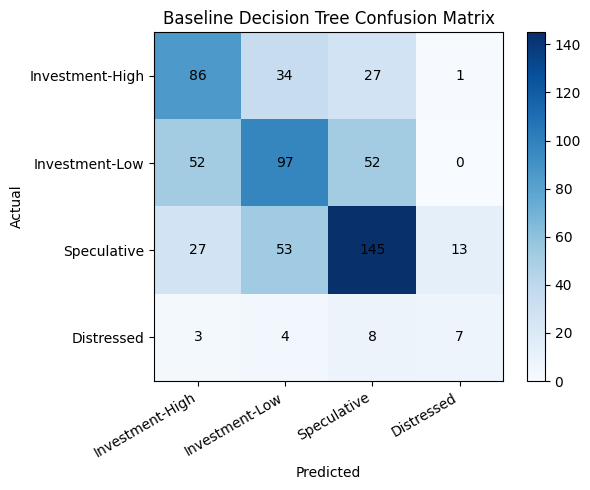

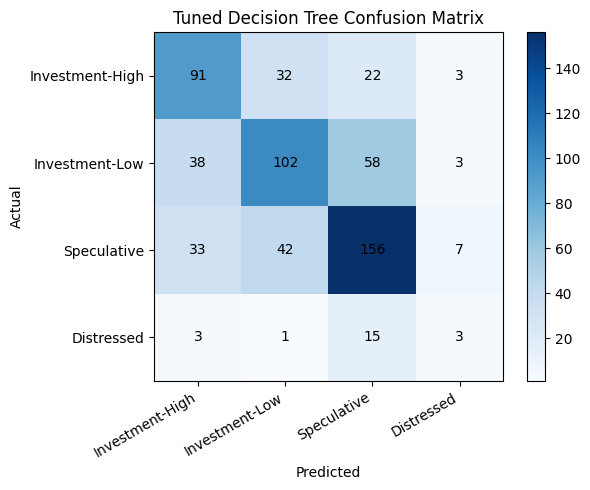

Final selected model: Tuned model
Reason for selecting it: Kept the tuned model because it improved: test accuracy, weighted F1, lower overfitting.


In [59]:
# Keep the fitted baseline pipeline as the reference model.
baseline_pipeline = pipeline
baseline_test_metrics = dict(metrics)

# Rebuild the train labels so we can measure training accuracy without changing the split.
y_train_labels = label_encoder.inverse_transform(y_train)

# Evaluate the baseline model on the training data and on the test data.
baseline_train_pred = baseline_pipeline.predict(X_train)
baseline_train_pred_labels = label_encoder.inverse_transform(baseline_train_pred.astype(int))
baseline_train_metrics = evaluate_predictions(y_train_labels, baseline_train_pred_labels, CLASS_ORDER)

minority_class = pd.Series(y_train_labels).value_counts().idxmin()
baseline_test_metrics["training_accuracy"] = baseline_train_metrics["accuracy"]
baseline_test_metrics["testing_accuracy"] = baseline_test_metrics["accuracy"]
baseline_test_metrics["minority_class"] = minority_class
baseline_test_metrics["minority_recall"] = baseline_test_metrics["classification_report_dict"][minority_class]["recall"]
baseline_test_metrics["overfit_gap"] = abs(baseline_train_metrics["accuracy"] - baseline_test_metrics["accuracy"])

# Set up a GridSearchCV run that tests the requested decision tree hyperparameters.
from sklearn.base import clone
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline

base_model = clone(baseline_pipeline.named_steps["model"])
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

tuning_search = GridSearchCV(
    estimator=Pipeline(
        steps=[
            ("preprocessor", build_preprocessor(numeric_columns, categorical_columns)),
            ("model", clone(base_model)),
        ]
    ),
    param_grid={
        "model__criterion": ["gini", "entropy", "log_loss"],
        "model__max_depth": [None, 3, 5, 7, 10, 15],
        "model__min_samples_split": [2, 5, 10, 20],
        "model__min_samples_leaf": [1, 2, 5, 10],
        "model__max_features": [None, "sqrt", "log2"],
        "model__class_weight": [None, "balanced"],
        "model__splitter": ["best", "random"],
    },
    cv=cv,
    scoring="f1_weighted",
    n_jobs=-1,
    refit=True,
)

# Fit the grid search on the training data only.
tuning_search.fit(X_train, y_train)
tuned_pipeline = tuning_search.best_estimator_

# Evaluate the tuned model on both the training and test sets.
tuned_train_pred = tuned_pipeline.predict(X_train)
tuned_test_pred = tuned_pipeline.predict(X_test)
tuned_train_pred_labels = label_encoder.inverse_transform(tuned_train_pred.astype(int))
tuned_test_pred_labels = label_encoder.inverse_transform(tuned_test_pred.astype(int))
tuned_train_metrics = evaluate_predictions(y_train_labels, tuned_train_pred_labels, CLASS_ORDER)
tuned_test_metrics = evaluate_predictions(y_test_labels, tuned_test_pred_labels, CLASS_ORDER)

tuned_test_metrics["training_accuracy"] = tuned_train_metrics["accuracy"]
tuned_test_metrics["testing_accuracy"] = tuned_test_metrics["accuracy"]
tuned_test_metrics["minority_class"] = minority_class
tuned_test_metrics["minority_recall"] = tuned_test_metrics["classification_report_dict"][minority_class]["recall"]
tuned_test_metrics["overfit_gap"] = abs(tuned_train_metrics["accuracy"] - tuned_test_metrics["accuracy"])

# Build a simple comparison table so the change is easy to read.
comparison = pd.DataFrame(
    [
        {
            "Model": "Baseline",
            "Training Accuracy": baseline_test_metrics["training_accuracy"],
            "Testing Accuracy": baseline_test_metrics["testing_accuracy"],
            "Weighted F1": baseline_test_metrics["weighted_f1"],
            "Macro F1": baseline_test_metrics["macro_f1"],
            "Minority Recall": baseline_test_metrics["minority_recall"],
            "Overfit Gap": baseline_test_metrics["overfit_gap"],
        },
        {
            "Model": "Tuned",
            "Training Accuracy": tuned_test_metrics["training_accuracy"],
            "Testing Accuracy": tuned_test_metrics["testing_accuracy"],
            "Weighted F1": tuned_test_metrics["weighted_f1"],
            "Macro F1": tuned_test_metrics["macro_f1"],
            "Minority Recall": tuned_test_metrics["minority_recall"],
            "Overfit Gap": tuned_test_metrics["overfit_gap"],
        },
        {
            "Model": "Difference (Tuned - Baseline)",
            "Training Accuracy": tuned_test_metrics["training_accuracy"] - baseline_test_metrics["training_accuracy"],
            "Testing Accuracy": tuned_test_metrics["testing_accuracy"] - baseline_test_metrics["testing_accuracy"],
            "Weighted F1": tuned_test_metrics["weighted_f1"] - baseline_test_metrics["weighted_f1"],
            "Macro F1": tuned_test_metrics["macro_f1"] - baseline_test_metrics["macro_f1"],
            "Minority Recall": tuned_test_metrics["minority_recall"] - baseline_test_metrics["minority_recall"],
            "Overfit Gap": tuned_test_metrics["overfit_gap"] - baseline_test_metrics["overfit_gap"],
        },
    ]
)

# Show the baseline model results first so the comparison stays clear.
print("Best hyperparameters:")
print(tuning_search.best_params_)
print()
print(f"Best cross-validation score (weighted F1): {tuning_search.best_score_:.6f}")
print()
print("Baseline metrics:")
print({
    "training_accuracy": baseline_test_metrics["training_accuracy"],
    "testing_accuracy": baseline_test_metrics["testing_accuracy"],
    "accuracy": baseline_test_metrics["accuracy"],
    "weighted_f1": baseline_test_metrics["weighted_f1"],
    "macro_f1": baseline_test_metrics["macro_f1"],
    "minority_class": baseline_test_metrics["minority_class"],
    "minority_recall": baseline_test_metrics["minority_recall"],
    "overfit_gap": baseline_test_metrics["overfit_gap"],
})
print()
print("Tuned model metrics:")
print({
    "training_accuracy": tuned_test_metrics["training_accuracy"],
    "testing_accuracy": tuned_test_metrics["testing_accuracy"],
    "accuracy": tuned_test_metrics["accuracy"],
    "weighted_f1": tuned_test_metrics["weighted_f1"],
    "macro_f1": tuned_test_metrics["macro_f1"],
    "minority_class": tuned_test_metrics["minority_class"],
    "minority_recall": tuned_test_metrics["minority_recall"],
    "overfit_gap": tuned_test_metrics["overfit_gap"],
})
print()
print("Difference between baseline and tuned metrics:")
print(comparison.to_string(index=False))
print()

# Print the full reports so the class-level behaviour is visible.
print("Baseline classification report:")
print(baseline_test_metrics["classification_report_text"])
print()
print("Tuned classification report:")
print(tuned_test_metrics["classification_report_text"])

# Plot both confusion matrices so the class errors are easy to compare.
def plot_confusion_matrix(matrix, title):
    fig, ax = plt.subplots(figsize=(7, 5))
    image = ax.imshow(matrix, cmap="Blues")
    ax.set_xticks(range(len(CLASS_ORDER)))
    ax.set_yticks(range(len(CLASS_ORDER)))
    ax.set_xticklabels(CLASS_ORDER, rotation=30, ha="right")
    ax.set_yticklabels(CLASS_ORDER)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_title(title)

    for row_index in range(matrix.shape[0]):
        for column_index in range(matrix.shape[1]):
            ax.text(column_index, row_index, matrix[row_index, column_index], ha="center", va="center", color="black")

    fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.show()

plot_confusion_matrix(np.array(baseline_test_metrics["confusion_matrix"]), "Baseline Decision Tree Confusion Matrix")
plot_confusion_matrix(np.array(tuned_test_metrics["confusion_matrix"]), "Tuned Decision Tree Confusion Matrix")

# Keep the tuned model only when it improves the requested metrics or reduces overfitting.
improved_metrics = []
if tuned_test_metrics["accuracy"] > baseline_test_metrics["accuracy"]:
    improved_metrics.append("test accuracy")
if tuned_test_metrics["weighted_f1"] > baseline_test_metrics["weighted_f1"]:
    improved_metrics.append("weighted F1")
if tuned_test_metrics["macro_f1"] > baseline_test_metrics["macro_f1"]:
    improved_metrics.append("macro F1")
if tuned_test_metrics["minority_recall"] > baseline_test_metrics["minority_recall"]:
    improved_metrics.append("minority-class recall")
if tuned_test_metrics["overfit_gap"] < baseline_test_metrics["overfit_gap"]:
    improved_metrics.append("lower overfitting")

keep_tuned = len(improved_metrics) > 0

if keep_tuned:
    selected_model_name = "Tuned model"
    selected_pipeline = tuned_pipeline
    selected_metrics = tuned_test_metrics
    selection_reason = "Kept the tuned model because it improved: " + ", ".join(improved_metrics) + "."
else:
    selected_model_name = "Baseline model"
    selected_pipeline = baseline_pipeline
    selected_metrics = baseline_test_metrics
    selection_reason = "Kept the baseline model because the tuned model did not improve the requested metrics overall."

best_pipeline = selected_pipeline
final_metrics = selected_metrics

print(f"Final selected model: {selected_model_name}")
print(f"Reason for selecting it: {selection_reason}")


## Explainable AI: SHAP Feature Importance

This section explains the final tuned decision tree selected after comparing the baseline and tuned models.
The selected tree uses the tuned parameters and the no-minmax preprocessing flow.

Final model used for SHAP:
DecisionTreeClassifier(class_weight='balanced', max_features='log2',
                       random_state=42, splitter='random')

Top SHAP features:


,Feature,Mean Absolute SHAP Value,Rank
0,returnOnAssets,0.058968,1
1,pretaxProfitMargin,0.037294,2
2,Sector_Basic Industries,0.029265,3
3,operatingCashFlowSalesRatio,0.027813,4
4,grossProfitMargin,0.026404,5
5,Sector_Health Care,0.026228,6
6,Sector_Public Utilities,0.025085,7
7,returnOnCapitalEmployed,0.024643,8
8,Sector_Energy,0.023595,9
9,returnOnEquity,0.021594,10


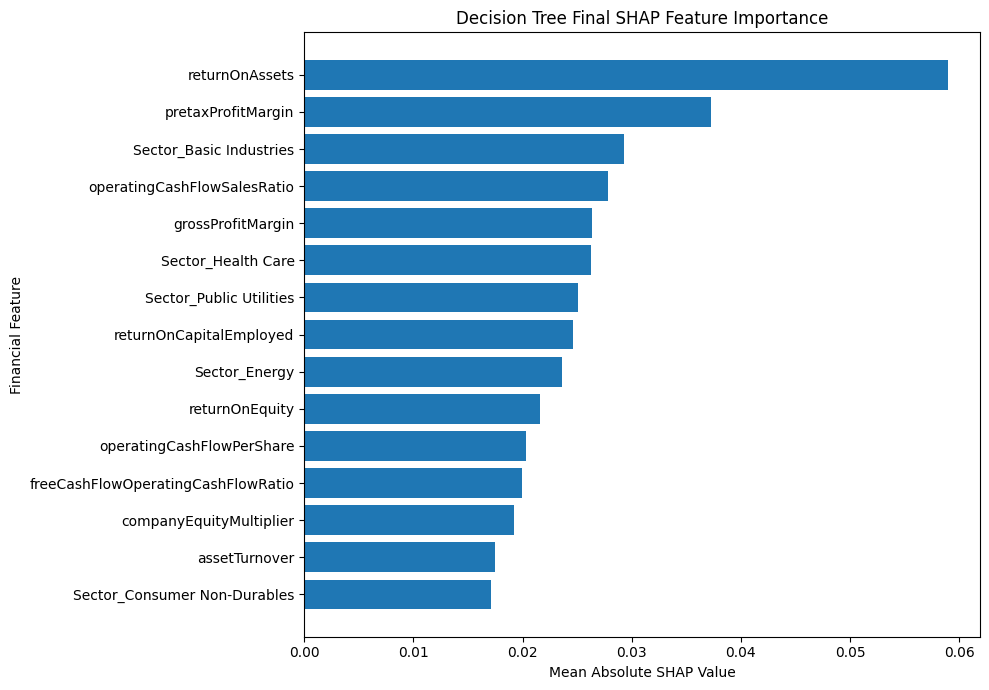

In [61]:
# Final SHAP Feature Importance
# This explains the final tuned decision tree from the comparison cells.
# The selected pipeline already includes the tuned Decision Tree settings and no min-max scaling.

final_pipeline = best_pipeline

# Extract the fitted preprocessing component and fitted model.
final_preprocessor = final_pipeline.named_steps["preprocessor"]
final_model = final_pipeline.named_steps["model"]

# Apply the already-fitted preprocessing steps.
X_train_transformed = final_preprocessor.transform(X_train)
X_test_transformed = final_preprocessor.transform(X_test)

# Convert sparse matrices into normal NumPy arrays.
if hasattr(X_train_transformed, "toarray"):
    X_train_transformed = X_train_transformed.toarray()

if hasattr(X_test_transformed, "toarray"):
    X_test_transformed = X_test_transformed.toarray()

# Retrieve the transformed feature names.
feature_names = final_preprocessor.get_feature_names_out()

# Remove prefixes such as num__ and cat__ from the displayed names.
display_feature_names = np.array(
    [str(name).split("__", 1)[-1] for name in feature_names]
)

# Use a fixed sample size to reduce SHAP processing time.
background_size = min(100, X_train_transformed.shape[0])
explanation_size = min(100, X_test_transformed.shape[0])

background_data = X_train_transformed[:background_size]
explanation_data = X_test_transformed[:explanation_size]

# Select the correct SHAP explainer.
if final_model.__class__.__name__ == "LogisticRegression":
    shap_explainer = shap.LinearExplainer(
        final_model,
        background_data,
        feature_names=feature_names
    )
else:
    shap_explainer = shap.TreeExplainer(final_model)

# Calculate SHAP values.
shap_result = shap_explainer(explanation_data)

# Support different SHAP output formats.
if isinstance(shap_result, list):
    shap_array = np.stack(
        [np.asarray(class_values) for class_values in shap_result],
        axis=-1
    )
elif hasattr(shap_result, "values"):
    shap_array = np.asarray(shap_result.values)
else:
    shap_array = np.asarray(shap_result)

# Calculate mean absolute SHAP values.
if shap_array.ndim == 2:
    mean_abs_shap = np.mean(np.abs(shap_array), axis=0)

elif shap_array.ndim == 3:
    if shap_array.shape[1] == len(feature_names):
        # Shape: observations, features, classes
        mean_abs_shap = np.mean(np.abs(shap_array), axis=(0, 2))

    elif shap_array.shape[2] == len(feature_names):
        # Shape: classes, observations, features
        mean_abs_shap = np.mean(np.abs(shap_array), axis=(0, 1))

    else:
        raise ValueError(
            f"Unexpected SHAP shape: {shap_array.shape}"
        )
else:
    raise ValueError(
        f"Unsupported SHAP dimensions: {shap_array.ndim}"
    )

# Create the ranked feature importance table.
shap_importance = pd.DataFrame(
    {
        "Feature": display_feature_names,
        "Mean Absolute SHAP Value": mean_abs_shap
    }
)

shap_importance = shap_importance.sort_values(
    "Mean Absolute SHAP Value",
    ascending=False
).reset_index(drop=True)

shap_importance["Rank"] = shap_importance.index + 1
shap_importance["Mean Absolute SHAP Value"] = (
    shap_importance["Mean Absolute SHAP Value"].round(6)
)

print("Final model used for SHAP:")
print(final_model)

print("\nTop SHAP features:")
display(shap_importance.head(15))

# Set the model name for the chart.
model_title_names = {
    "DecisionTreeClassifier": "Decision Tree",
    "RandomForestClassifier": "Random Forest",
    "XGBClassifier": "XGBoost",
    "LogisticRegression": "Logistic Regression"
}

model_title = model_title_names.get(
    final_model.__class__.__name__,
    final_model.__class__.__name__
)

# Plot the 15 most influential features.
top_features = shap_importance.head(15).sort_values(
    "Mean Absolute SHAP Value",
    ascending=True
)

plt.figure(figsize=(10, 7))
plt.barh(
    top_features["Feature"],
    top_features["Mean Absolute SHAP Value"]
)

plt.xlabel("Mean Absolute SHAP Value")
plt.ylabel("Financial Feature")
plt.title(f"{model_title} Final SHAP Feature Importance")
plt.tight_layout()
plt.show()